# Phase 1 — Universe Selection & Exploratory Data Analysis

**Project:** Sector-Comparative Indian Equity Forecasting with LSTM
**Notebook goal:** load the *locked* investable universe, pull 5 years of daily
adjusted prices for all 40 tickers, cache them locally, and run basic EDA
(coverage, missing values, split/bonus adjustment check, returns, correlations).

### How the universe is sourced
- **Sector membership** comes from the NSE sectoral-index constituents
  (Nifty IT / Bank / Financial Services / Energy / FMCG), curated as candidate
  pools in `src/universe.py`.
- **Ranking** is done by *live market capitalisation* pulled from Yahoo Finance,
  keeping the top 10 per sector.
- The result is **locked and dated** in `config/universe.json`. This notebook
  *reads* that locked file — it does **not** re-rank — so the universe stays
  frozen between explicit refreshes (`python src/universe.py`). This honours the
  project's "universe locked and dated" rule.

> Run top-to-bottom with no manual intervention. Data is cached under `data/raw/`
> (gitignored); the first run downloads from Yahoo, later runs reuse the cache.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make src/ importable whether run from repo root or notebooks/.
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import (
    load_universe, flat_tickers, ticker_to_sector,
    download_history, adj_close_panel,
)

PLOTS_DIR = ROOT / "results" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="notebook")
print("Repo root:", ROOT)

Repo root: /Users/pranav/Documents/GitHub/stock-lstm-forecast


## 1. Load the locked universe

`config/universe.json` was produced by `src/universe.py`. If you want to refresh
the market-cap snapshot, run `python src/universe.py` from the repo root — do
**not** re-rank inside modelling notebooks.

In [2]:
universe = load_universe()
meta = universe["metadata"]
print("Universe metadata")
print("-" * 40)
for k in ["fetch_date", "top_n_per_sector", "n_sectors", "n_tickers",
          "market_cap_source", "candidate_pool_as_of", "currency"]:
    print(f"  {k:<20}: {meta[k]}")
print("\nExcluded (no market cap on Yahoo):", meta.get("excluded_no_market_cap"))
print("\nSourcing note:\n ", meta["sourcing_note"])

Universe metadata
----------------------------------------
  fetch_date          : 2026-07-14
  top_n_per_sector    : 10
  n_sectors           : 4
  n_tickers           : 40
  market_cap_source   : Yahoo Finance via yfinance (live at fetch time)
  candidate_pool_as_of: 2026-07-14
  currency            : INR

Excluded (no market cap on Yahoo): {'Information Technology': ['LTIM.NS']}

Sourcing note:
  Sector membership comes from NSE sectoral-index constituents (hand-curated superset). Market caps are pulled live from Yahoo Finance and used to rank each pool to the top N. Cross-check against Moneycontrol / ET Markets before relying on this list.


In [3]:
# Flatten the universe into a tidy table for display.
rows = []
for sector, members in universe["sectors"].items():
    for m in members:
        rows.append({
            "sector": sector, "rank": m["rank"], "ticker": m["ticker"],
            "market_cap_lakh_cr": m["market_cap_lakh_cr"],
        })
universe_df = pd.DataFrame(rows)
print(f"{len(universe_df)} tickers across {universe_df['sector'].nunique()} sectors")
universe_df

40 tickers across 4 sectors


,sector,rank,ticker,market_cap_lakh_cr
0,Information Technology,1,TCS.NS,7.89
1,Information Technology,2,INFY.NS,4.46
2,Information Technology,3,HCLTECH.NS,3.30
3,Information Technology,4,WIPRO.NS,1.77
4,Information Technology,5,TECHM.NS,1.33
5,Information Technology,6,OFSS.NS,1.02
6,Information Technology,7,PERSISTENT.NS,0.81
7,Information Technology,8,COFORGE.NS,0.68
8,Information Technology,9,MPHASIS.NS,0.46
9,Information Technology,10,LTTS.NS,0.35


In [4]:
# Top 10 per sector, side by side.
for sector, g in universe_df.groupby("sector"):
    print(f"\n{sector}")
    print("-" * len(sector))
    for _, r in g.sort_values("rank").iterrows():
        print(f"  {int(r['rank']):>2}. {r['ticker']:<16} Rs {r['market_cap_lakh_cr']:>6.2f} lakh-cr")


Banking & Financial Services
----------------------------
   1. HDFCBANK.NS      Rs  12.60 lakh-cr
   2. ICICIBANK.NS     Rs  10.11 lakh-cr
   3. SBIN.NS          Rs   9.57 lakh-cr
   4. BAJFINANCE.NS    Rs   6.36 lakh-cr
   5. AXISBANK.NS      Rs   4.10 lakh-cr
   6. KOTAKBANK.NS     Rs   3.83 lakh-cr
   7. BAJAJFINSV.NS    Rs   3.05 lakh-cr
   8. SHRIRAMFIN.NS    Rs   2.47 lakh-cr
   9. SBILIFE.NS       Rs   1.86 lakh-cr
  10. JIOFIN.NS        Rs   1.59 lakh-cr

Energy
------
   1. RELIANCE.NS      Rs  17.55 lakh-cr
   2. ADANIPOWER.NS    Rs   4.16 lakh-cr
   3. NTPC.NS          Rs   3.41 lakh-cr
   4. ONGC.NS          Rs   3.13 lakh-cr
   5. POWERGRID.NS     Rs   2.66 lakh-cr
   6. COALINDIA.NS     Rs   2.65 lakh-cr
   7. ADANIGREEN.NS    Rs   2.55 lakh-cr
   8. IOC.NS           Rs   1.98 lakh-cr
   9. ADANIENSOL.NS    Rs   1.98 lakh-cr
  10. BPCL.NS          Rs   1.31 lakh-cr

FMCG
----
   1. HINDUNILVR.NS    Rs   5.01 lakh-cr
   2. ITC.NS           Rs   3.50 lakh-cr
   3. NESTLEI

## 2. Pull 5 years of daily adjusted data

`download_history` fetches OHLCV **and** `Adj Close` (`auto_adjust=False`) and
caches one CSV per ticker under `data/raw/`. We model on **`Adj Close`** so that
splits and bonus issues — frequent for Indian equities — are handled correctly.

In [5]:
tickers = flat_tickers(universe)
tk2sec = ticker_to_sector(universe)

data = download_history(tickers, years=5)   # cached after first run
print(f"\nLoaded {len(data)}/{len(tickers)} tickers.")

Fetching 40 tickers | 2021-07-14 -> 2026-07-14 (force=False)
  [ 1/40] TCS.NS           cached  (1237 rows)
  [ 2/40] INFY.NS          cached  (1237 rows)
  [ 3/40] HCLTECH.NS       cached  (1237 rows)
  [ 4/40] WIPRO.NS         cached  (1237 rows)
  [ 5/40] TECHM.NS         cached  (1237 rows)
  [ 6/40] OFSS.NS          cached  (1237 rows)
  [ 7/40] PERSISTENT.NS    cached  (1237 rows)
  [ 8/40] COFORGE.NS       cached  (1237 rows)
  [ 9/40] MPHASIS.NS       cached  (1237 rows)
  [10/40] LTTS.NS          cached  (1237 rows)
  [11/40] HDFCBANK.NS      cached  (1237 rows)
  [12/40] ICICIBANK.NS     cached  (1237 rows)
  [13/40] SBIN.NS          cached  (1237 rows)
  [14/40] BAJFINANCE.NS    cached  (1237 rows)
  [15/40] AXISBANK.NS      cached  (1237 rows)
  [16/40] KOTAKBANK.NS     cached  (1237 rows)
  [17/40] BAJAJFINSV.NS    cached  (1237 rows)
  [18/40] SHRIRAMFIN.NS    cached  (1237 rows)
  [19/40] SBILIFE.NS       cached  (1237 rows)
  [20/40] JIOFIN.NS        cached  (716 rows)


In [6]:
# Wide Adj Close panel (one column per ticker).
panel = adj_close_panel(data)

# The most recent row can be an unsettled/partial session (all-NaN) — drop
# trailing rows that are entirely missing across the universe.
all_nan_tail = panel.isna().all(axis=1)
if all_nan_tail.iloc[-1]:
    n_drop = int(all_nan_tail[::-1].cumprod().sum())
    print(f"Dropping {n_drop} trailing all-NaN row(s): "
          f"{list(panel.index[-n_drop:].date)}")
    panel = panel.iloc[:-n_drop]

print(f"Adj Close panel: {panel.shape[0]} rows x {panel.shape[1]} tickers")
print(f"Date range: {panel.index.min().date()} -> {panel.index.max().date()}")
panel.tail(3).iloc[:, :5]

Dropping 1 trailing all-NaN row(s): [datetime.date(2026, 7, 13)]
Adj Close panel: 1236 rows x 40 tickers
Date range: 2021-07-14 -> 2026-07-10


,TCS.NS,INFY.NS,HCLTECH.NS,WIPRO.NS,TECHM.NS
Date,,,,,
2026-07-08,2057.5,1069.300049,1145.599976,172.720001,1428.800049
2026-07-09,2049.5,1050.800049,1150.400024,172.759995,1426.300049
2026-07-10,2069.0,1068.000000,1164.099976,175.460007,1454.800049


## 3. Data coverage & integrity

Not every ticker has a full 5 years. **JIOFIN.NS** (Jio Financial Services) only
listed in **August 2023** after its demerger from Reliance, so it has ~2 years
of history — a real data limitation we flag now rather than discover mid-training.

In [7]:
cov = []
for tk, df in data.items():
    s = df["Adj Close"].dropna()
    cov.append({
        "ticker": tk, "sector": tk2sec[tk], "rows": len(s),
        "start": s.index.min().date(), "end": s.index.max().date(),
        "n_missing_adj_close": int(df["Adj Close"].isna().sum()),
    })
coverage = pd.DataFrame(cov).sort_values("rows")
print("Shortest histories (potential modelling caveats):")
print(coverage.head(5).to_string(index=False))
print(f"\nMedian rows: {int(coverage['rows'].median())} | "
      f"min: {coverage['rows'].min()} | max: {coverage['rows'].max()}")
coverage.sort_values(["sector", "ticker"])

Shortest histories (potential modelling caveats):
      ticker                       sector  rows      start        end  n_missing_adj_close
   JIOFIN.NS Banking & Financial Services   715 2023-08-21 2026-07-10                    1
     NTPC.NS                       Energy  1236 2021-07-14 2026-07-10                    1
     ONGC.NS                       Energy  1236 2021-07-14 2026-07-10                    1
POWERGRID.NS                       Energy  1236 2021-07-14 2026-07-10                    1
COALINDIA.NS                       Energy  1236 2021-07-14 2026-07-10                    1

Median rows: 1236 | min: 715 | max: 1236


,ticker,sector,rows,start,end,n_missing_adj_close
14,AXISBANK.NS,Banking & Financial Services,1236,2021-07-14,2026-07-10,1
16,BAJAJFINSV.NS,Banking & Financial Services,1236,2021-07-14,2026-07-10,1
13,BAJFINANCE.NS,Banking & Financial Services,1236,2021-07-14,2026-07-10,1
10,HDFCBANK.NS,Banking & Financial Services,1236,2021-07-14,2026-07-10,1
11,ICICIBANK.NS,Banking & Financial Services,1236,2021-07-14,2026-07-10,1
19,JIOFIN.NS,Banking & Financial Services,715,2023-08-21,2026-07-10,1
15,KOTAKBANK.NS,Banking & Financial Services,1236,2021-07-14,2026-07-10,1
18,SBILIFE.NS,Banking & Financial Services,1236,2021-07-14,2026-07-10,1
12,SBIN.NS,Banking & Financial Services,1236,2021-07-14,2026-07-10,1
17,SHRIRAMFIN.NS,Banking & Financial Services,1236,2021-07-14,2026-07-10,1


### Missing values
Beyond the trailing unsettled session, interior gaps would indicate holidays
misaligned across tickers or data issues. We check the aligned panel.

In [8]:
missing = panel.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
if len(missing):
    print("Tickers with missing values in the aligned panel (mostly pre-listing "
          "gaps, e.g. JIOFIN before Aug-2023):")
    print(missing.to_string())
else:
    print("No missing values in the aligned Adj Close panel.")

# Fraction of the full window each ticker actually covers.
coverage["coverage_pct"] = (coverage["rows"] / coverage["rows"].max() * 100).round(1)
print("\nCoverage vs longest series:")
print(coverage.sort_values("coverage_pct")[["ticker", "sector", "rows",
      "coverage_pct"]].head(5).to_string(index=False))

Tickers with missing values in the aligned panel (mostly pre-listing gaps, e.g. JIOFIN before Aug-2023):
JIOFIN.NS    521

Coverage vs longest series:
    ticker                       sector  rows  coverage_pct
 JIOFIN.NS Banking & Financial Services   715          57.8
HCLTECH.NS       Information Technology  1236         100.0
  WIPRO.NS       Information Technology  1236         100.0
  TECHM.NS       Information Technology  1236         100.0
   OFSS.NS       Information Technology  1236         100.0


## 4. Split / bonus adjustment check

Indian stocks issue splits and bonuses often. With `auto_adjust=False`, Yahoo
gives both raw `Close` and back-adjusted `Adj Close`. Where a corporate action
happened, historical `Adj Close` sits **below** raw `Close`, so the ratio
`Adj Close / Close` is < 1 in the past and converges to ~1 at the latest date.
A large historical divergence is evidence the adjustment is doing its job.

In [9]:
adj_check = []
for tk, df in data.items():
    d = df[["Close", "Adj Close"]].dropna()
    if d.empty:
        continue
    ratio = d["Adj Close"] / d["Close"]
    adj_check.append({
        "ticker": tk, "sector": tk2sec[tk],
        "min_adj_ratio": round(ratio.min(), 4),
        "latest_adj_ratio": round(ratio.iloc[-1], 4),
        "max_hist_discount_pct": round((1 - ratio.min()) * 100, 2),
    })
adj_df = pd.DataFrame(adj_check).sort_values("max_hist_discount_pct", ascending=False)
print("Largest historical adjustment discounts (splits/bonuses/dividends):")
print(adj_df.head(10).to_string(index=False))
print("\nInterpretation: a large 'max_hist_discount_pct' means substantial "
      "corporate actions were back-adjusted. ~0% means little/no adjustment.")

Largest historical adjustment discounts (splits/bonuses/dividends):
      ticker                 sector  min_adj_ratio  latest_adj_ratio  max_hist_discount_pct
COALINDIA.NS                 Energy         0.6598               1.0                  34.02
     BPCL.NS                 Energy         0.7116               1.0                  28.84
     ONGC.NS                 Energy         0.7319               1.0                  26.81
      IOC.NS                 Energy         0.7380               1.0                  26.20
POWERGRID.NS                 Energy         0.7729               1.0                  22.71
     OFSS.NS Information Technology         0.7988               1.0                  20.12
  HCLTECH.NS Information Technology         0.8163               1.0                  18.37
      ITC.NS                   FMCG         0.8177               1.0                  18.23
    TECHM.NS Information Technology         0.8181               1.0                  18.19
     NTPC.NS

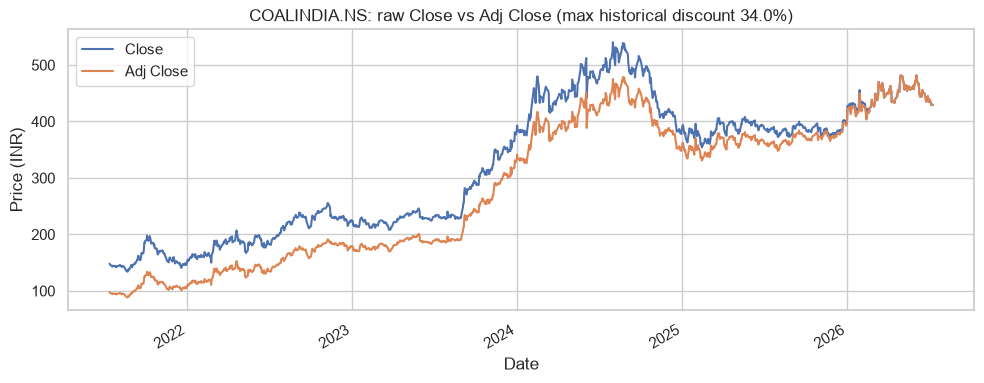

In [10]:
# Visualise Close vs Adj Close for the ticker with the biggest adjustment.
top_adj = adj_df.iloc[0]["ticker"]
d = data[top_adj][["Close", "Adj Close"]].dropna()
fig, ax = plt.subplots(figsize=(10, 4))
d.plot(ax=ax)
ax.set_title(f"{top_adj}: raw Close vs Adj Close "
             f"(max historical discount {adj_df.iloc[0]['max_hist_discount_pct']:.1f}%)")
ax.set_ylabel("Price (INR)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "eda_adjustment_check.png", dpi=110)
plt.show()

## 5. Price history by sector

Prices are rebased to 100 at each ticker's first available date so names of very
different absolute price can be compared on one axis.

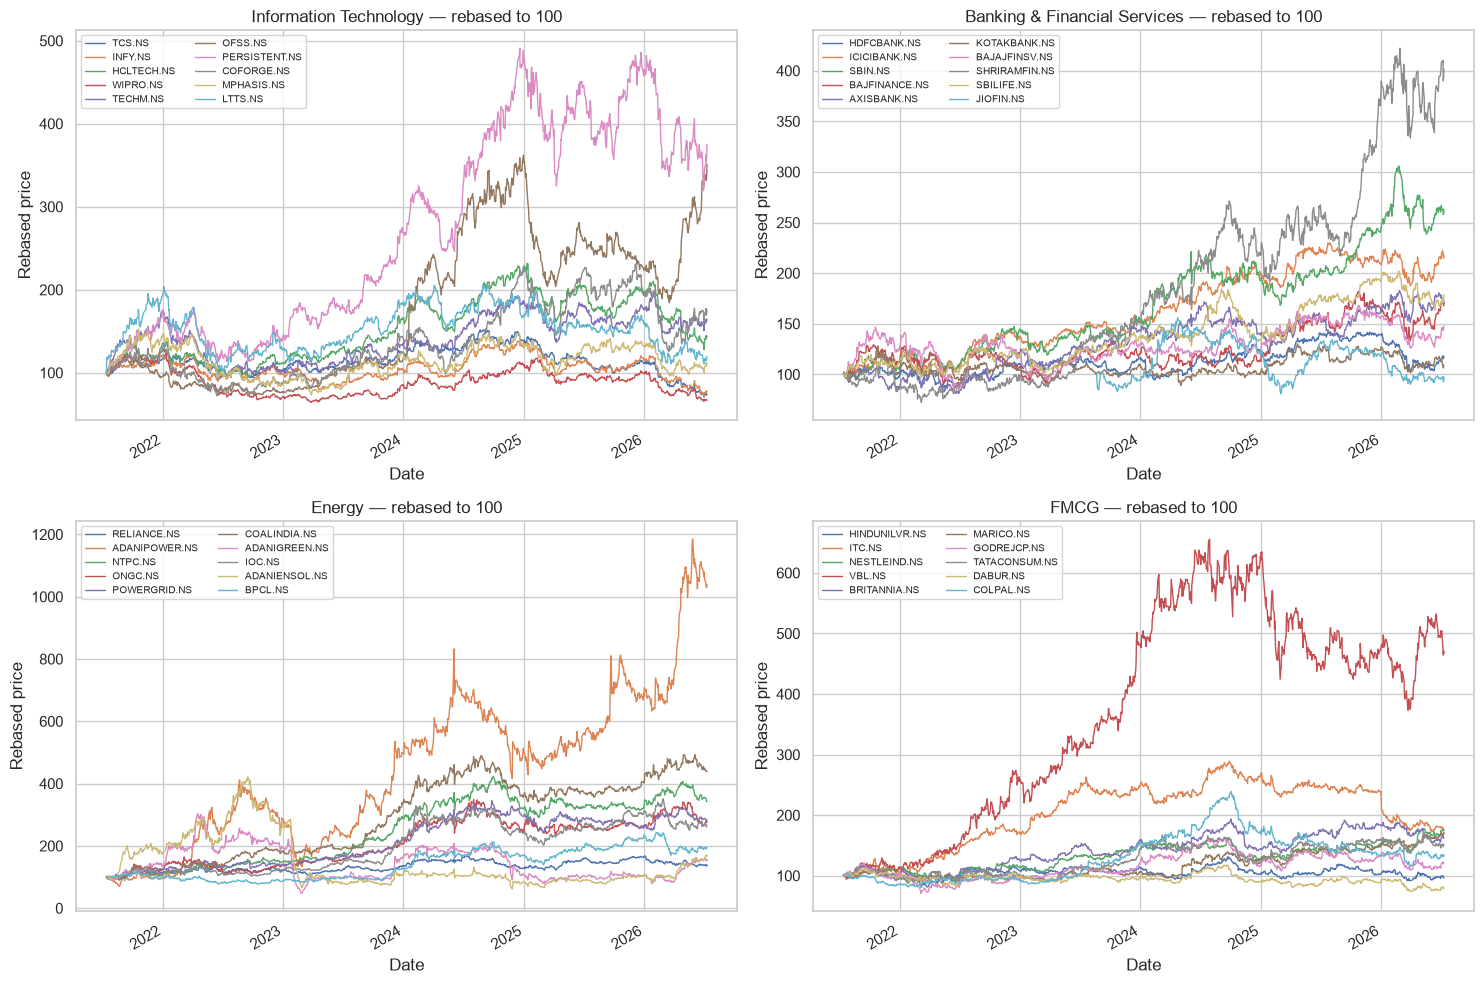

In [11]:
sectors = list(universe["sectors"].keys())
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, sector in zip(axes.ravel(), sectors):
    members = [m["ticker"] for m in universe["sectors"][sector]]
    sub = panel[members].dropna(how="all")
    rebased = sub / sub.apply(lambda c: c.loc[c.first_valid_index()]) * 100
    rebased.plot(ax=ax, linewidth=1)
    ax.set_title(f"{sector} — rebased to 100")
    ax.set_ylabel("Rebased price")
    ax.legend(fontsize=7, ncol=2, loc="upper left")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "eda_price_history_by_sector.png", dpi=110)
plt.show()

## 6. Daily returns

Returns (not raw prices) are the modelling substrate. We summarise their scale
per sector — annualised volatility hints at how hard each name is to predict.

In [12]:
returns = panel.pct_change().dropna(how="all")

ret_summary = []
for tk in panel.columns:
    r = returns[tk].dropna()
    if len(r) < 30:
        continue
    ret_summary.append({
        "ticker": tk, "sector": tk2sec[tk],
        "mean_daily_%": round(r.mean() * 100, 3),
        "daily_vol_%": round(r.std() * 100, 2),
        "ann_vol_%": round(r.std() * np.sqrt(252) * 100, 1),
    })
ret_df = pd.DataFrame(ret_summary)
print("Annualised volatility by sector (median):")
print(ret_df.groupby("sector")["ann_vol_%"].median().round(1).to_string())
print("\nMost/least volatile names:")
print(ret_df.sort_values("ann_vol_%", ascending=False).head(3).to_string(index=False))
print(ret_df.sort_values("ann_vol_%").head(3).to_string(index=False))

Annualised volatility by sector (median):
sector
Banking & Financial Services    24.5
Energy                          28.7
FMCG                            21.8
Information Technology          29.8

Most/least volatile names:
       ticker sector  mean_daily_%  daily_vol_%  ann_vol_%
ADANIGREEN.NS Energy         0.090         3.28       52.0
ADANIENSOL.NS Energy         0.095         3.22       51.1
ADANIPOWER.NS Energy         0.239         3.15       50.1
       ticker sector  mean_daily_%  daily_vol_%  ann_vol_%
 NESTLEIND.NS   FMCG         0.053         1.20       19.0
       ITC.NS   FMCG         0.053         1.26       20.0
HINDUNILVR.NS   FMCG         0.006         1.28       20.3


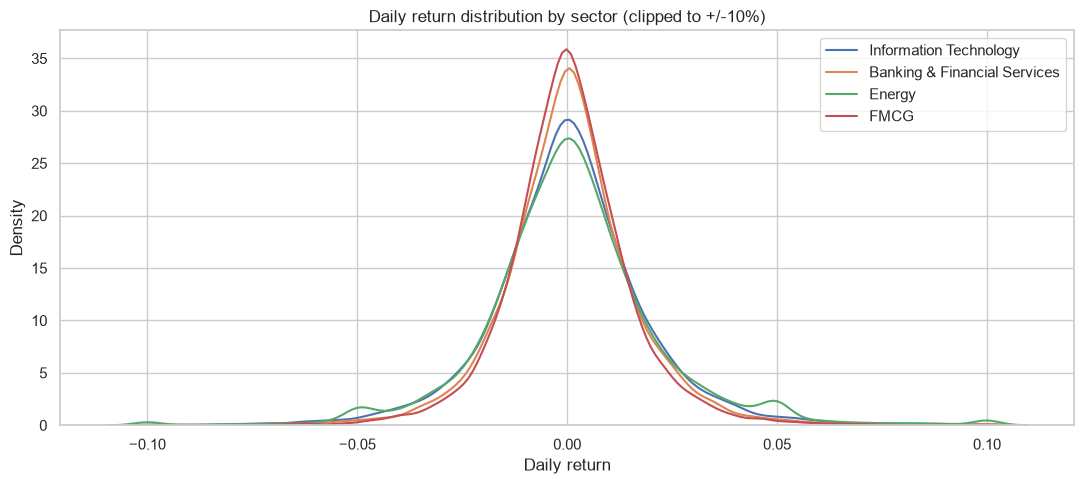

In [13]:
# Distribution of daily returns per sector (fat tails are expected).
fig, ax = plt.subplots(figsize=(11, 5))
for sector in sectors:
    members = [m["ticker"] for m in universe["sectors"][sector]]
    r = returns[members].stack().dropna()
    sns.kdeplot(r.clip(-0.1, 0.1), label=sector, ax=ax, linewidth=1.5)
ax.set_title("Daily return distribution by sector (clipped to +/-10%)")
ax.set_xlabel("Daily return")
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "eda_return_distribution.png", dpi=110)
plt.show()

## 7. Correlations — within and across sectors

We expect **high intra-sector** correlation (names share sector-wide drivers) and
**lower cross-sector** correlation. Return correlations (not price levels) avoid
spurious trend-driven correlation.

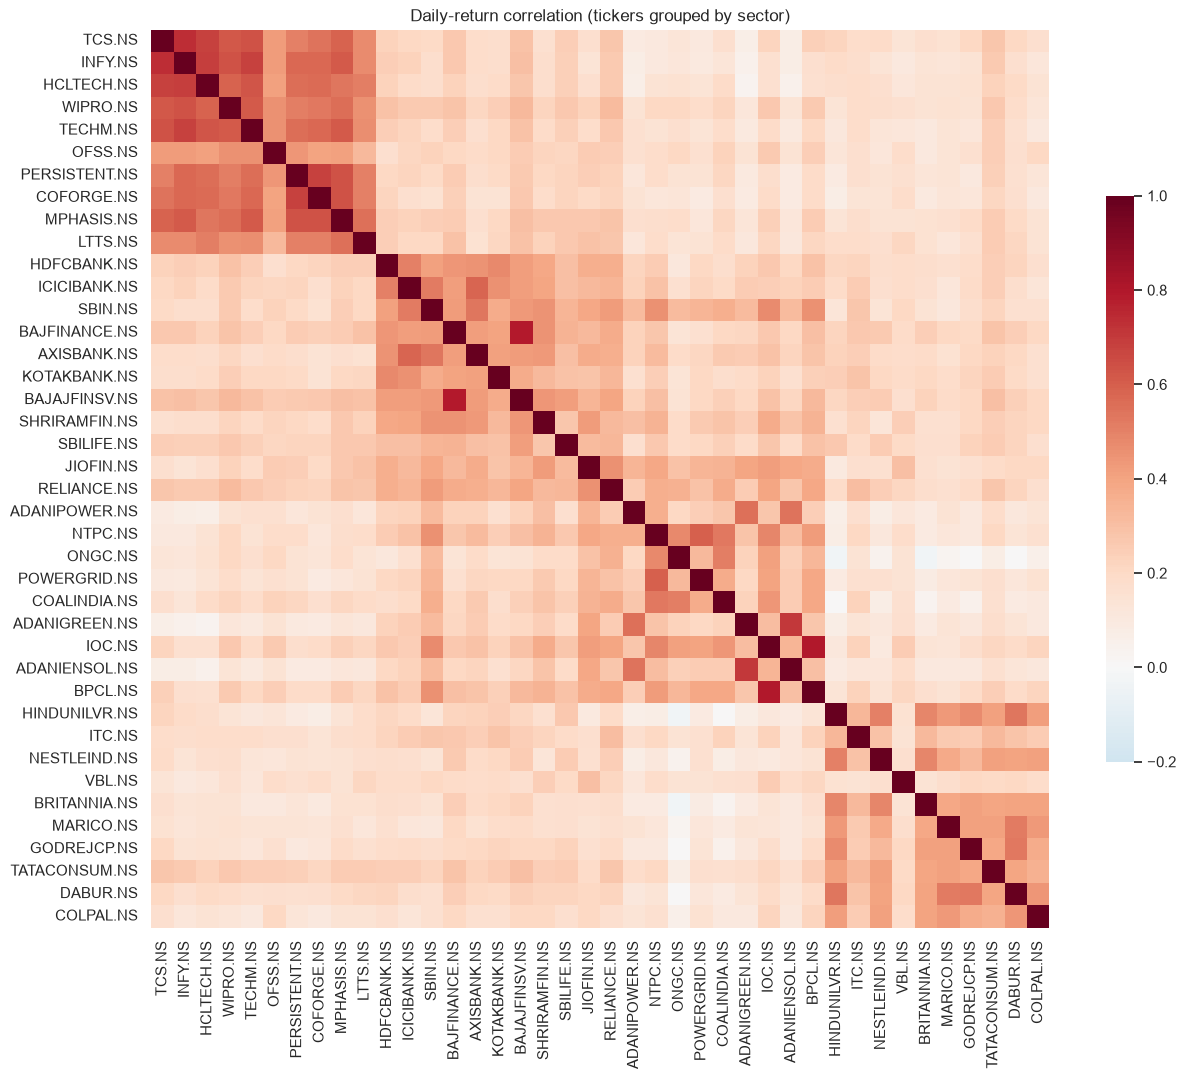

In [14]:
# Order columns by sector so the block structure is visible.
ordered = [m["ticker"] for s in sectors for m in universe["sectors"][s]]
corr = returns[ordered].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-0.2, vmax=1.0,
            square=True, cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Daily-return correlation (tickers grouped by sector)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "eda_correlation_heatmap.png", dpi=110)
plt.show()

In [15]:
# Quantify intra- vs inter-sector correlation.
import itertools
intra, inter = [], []
for a, b in itertools.combinations(ordered, 2):
    c = corr.loc[a, b]
    if np.isnan(c):
        continue
    (intra if tk2sec[a] == tk2sec[b] else inter).append(c)

print(f"Mean INTRA-sector return correlation: {np.mean(intra):.3f}  (n={len(intra)})")
print(f"Mean INTER-sector return correlation: {np.mean(inter):.3f}  (n={len(inter)})")

print("\nPer-sector mean intra-correlation:")
for sector in sectors:
    members = [m["ticker"] for m in universe["sectors"][sector]]
    vals = [corr.loc[a, b] for a, b in itertools.combinations(members, 2)
            if not np.isnan(corr.loc[a, b])]
    print(f"  {sector:<32}: {np.mean(vals):.3f}")

Mean INTRA-sector return correlation: 0.418  (n=180)
Mean INTER-sector return correlation: 0.194  (n=600)

Per-sector mean intra-correlation:
  Information Technology          : 0.545
  Banking & Financial Services    : 0.407
  Energy                          : 0.367
  FMCG                            : 0.352


## Phase 1 takeaways

- **Universe:** 40 tickers (top-10 by live market cap in 4 NSE sectors), locked
  and dated in `config/universe.json`. LTIMindtree (LTIM) was dropped from IT
  because Yahoo carries no data for it — recorded in the config metadata.
- **Coverage:** most series span the full ~5 years (~1237 trading days).
  **JIOFIN** is the notable exception (~2 years, listed Aug-2023) and will need
  care in train/val/test sizing.
- **Adjustment:** `Adj Close` shows clear back-adjustment for corporate actions,
  confirming we should model on adjusted prices.
- **Structure:** intra-sector return correlation exceeds inter-sector, as
  expected — sector-comparative framing is justified.

**Next (Phase 2):** engineer per-stock features (returns, MAs, RSI, MACD,
volatility, volume ratio), drop indicator warm-up NaNs, and build a
`StandardScaler` pipeline fit on **training data only**.